In [1]:
import xarray as xr 
import tams
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

* This part of the code can be found in predata.ipynb

In [2]:
root = "./"
pr_pre = "precipitation_IMERG_1999_WA" # This can be changed to match the data and resolution.
data_path_pr = f"{root}TFM/{pr_pre}_0.25x0.25.nc"

temp_pre = "tb_merg_1999_WA" # This can be changed to match the data and resolution.
data_path_temp = f"{root}TFM/{temp_pre}_0.25x0.25.nc"

In [3]:
pr_data = xr.open_dataset(data_path_pr)
pr_data = pr_data.transpose("time", "lat", "lon") # In order to put dims correctly time,lat,lon.
temp_data = xr.open_dataset(data_path_temp)

In [4]:
ds_full = xr.merge([temp_data, pr_data])
ds_full = ds_full.rename({"Tb":"ctt","precipitation":"pr"})


In [13]:
print(ds_full.pr.isnull().sum())

<xarray.DataArray 'pr' ()> Size: 8B
array(0)
Attributes:
    units:             mm/hr
    DimensionNames:    time,lon,lat
    Units:             mm/hr
    CodeMissingValue:  -9999.9
    LongName:          \nComplete merged microwave-infrared (gauge-adjusted)\...


In [10]:
print(ds_full.ctt.isnull().sum())

<xarray.DataArray 'ctt' ()> Size: 8B
array(1156241)
Attributes:
    standard_name:  brightness_temperature
    units:          K


In [ ]:
null_mask = ds_full.ctt.isnull()
times_with_nulls = ds_full.time.where(null_mask.any(dim=["lat", "lon"]), drop=True)
print("Timestamps with at least one null value:")
print(times_with_nulls.values)

Timestamps with at least one null value:
['1999-06-01T13:00:00.000000000' '1999-06-02T15:00:00.000000000'
 '1999-06-03T09:30:00.000000000' '1999-06-06T10:30:00.000000000'
 '1999-06-06T11:00:00.000000000' '1999-06-07T12:30:00.000000000'
 '1999-06-07T13:00:00.000000000' '1999-06-16T01:30:00.000000000'
 '1999-06-18T12:30:00.000000000' '1999-06-22T09:30:00.000000000'
 '1999-06-23T09:00:00.000000000' '1999-06-23T09:30:00.000000000'
 '1999-06-23T10:00:00.000000000' '1999-06-23T10:30:00.000000000'
 '1999-07-02T12:30:00.000000000' '1999-07-02T13:00:00.000000000'
 '1999-07-09T10:30:00.000000000' '1999-07-12T12:00:00.000000000'
 '1999-07-16T11:00:00.000000000' '1999-07-19T18:00:00.000000000'
 '1999-07-20T02:00:00.000000000' '1999-07-20T11:00:00.000000000'
 '1999-07-21T11:00:00.000000000' '1999-07-25T10:30:00.000000000'
 '1999-07-26T21:00:00.000000000' '1999-07-26T21:30:00.000000000'
 '1999-07-28T16:00:00.000000000' '1999-07-28T16:30:00.000000000'
 '1999-08-01T12:00:00.000000000' '1999-08-02T14:0

In [5]:
null_coords_df = ds_full.ctt.where(ds_full.ctt.isnull(), drop=True).to_dataframe().reset_index()

min_lat = null_coords_df['lat'].min()
max_lat = null_coords_df['lat'].max()
min_lon = null_coords_df['lon'].min()
max_lon = null_coords_df['lon'].max()

# 2. Print the bounding box
print(f"The NaNs are located between:")
print(f"Latitude:  {min_lat}° to {max_lat}°")
print(f"Longitude: {min_lon}° to {max_lon}°")

The NaNs are located between:
Latitude:  0.25° to 29.75°
Longitude: -39.75° to 49.75°


Do the original coordinates match exactly? True
                  time   lat    lon
0  1999-06-01 13:00:00  0.25 -39.75
1  1999-06-01 13:00:00  0.25 -39.50
2  1999-06-01 13:00:00  0.25 -39.25
3  1999-06-01 13:00:00  0.25 -39.00
4  1999-06-01 13:00:00  0.25 -38.75
5  1999-06-01 13:00:00  0.25 -38.50
6  1999-06-01 13:00:00  0.25 -38.25
7  1999-06-01 13:00:00  0.25 -38.00
8  1999-06-01 13:00:00  0.25 -37.75
9  1999-06-01 13:00:00  0.25 -37.50
10 1999-06-01 13:00:00  0.25 -37.25
11 1999-06-01 13:00:00  0.25 -37.00
12 1999-06-01 13:00:00  0.25 -36.75
13 1999-06-01 13:00:00  0.25 -36.50
14 1999-06-01 13:00:00  0.25 -36.25
15 1999-06-01 13:00:00  0.25 -36.00
16 1999-06-01 13:00:00  0.25 -35.75
17 1999-06-01 13:00:00  0.25 -35.50
18 1999-06-01 13:00:00  0.25 -35.25
19 1999-06-01 13:00:00  0.25 -35.00


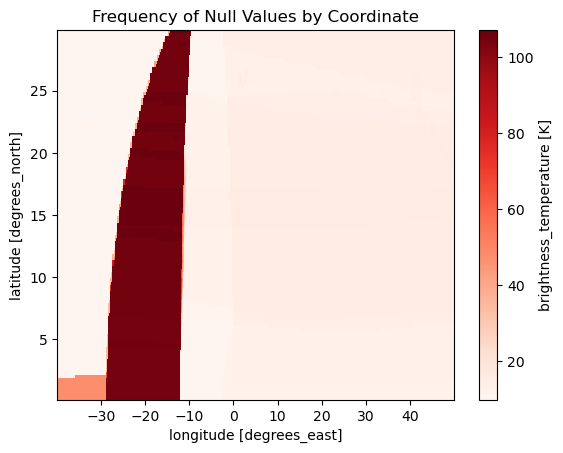

In [18]:
coords_match = temp_data.lat.equals(pr_data.lat) and temp_data.lon.equals(pr_data.lon)
print(f"Do the original coordinates match exactly? {coords_match}")

null_coords_df = ds_full.ctt.where(ds_full.ctt.isnull(), drop=True).to_dataframe().reset_index()
print(null_coords_df[['time', 'lat', 'lon']].head(20))

null_map = ds_full.ctt.isnull().sum(dim='time')
null_map.plot(cmap='Reds')
plt.title("Frequency of Null Values by Coordinate")
plt.show()

In [6]:
total_blackout_mask = ds_full.ctt.isnull().all(dim=['lat', 'lon'])
blackout_times = ds_full.time.where(total_blackout_mask, drop=True).values
print(f"Found {len(blackout_times)} 'Total Blackout' frames!")
if len(blackout_times) > 0:
    print("Here are the exact dates and times the satellite data completely failed:")
    for t in blackout_times:
        print(t)

Found 1 'Total Blackout' frames!
Here are the exact dates and times the satellite data completely failed:
1999-08-12T11:00:00.000000000


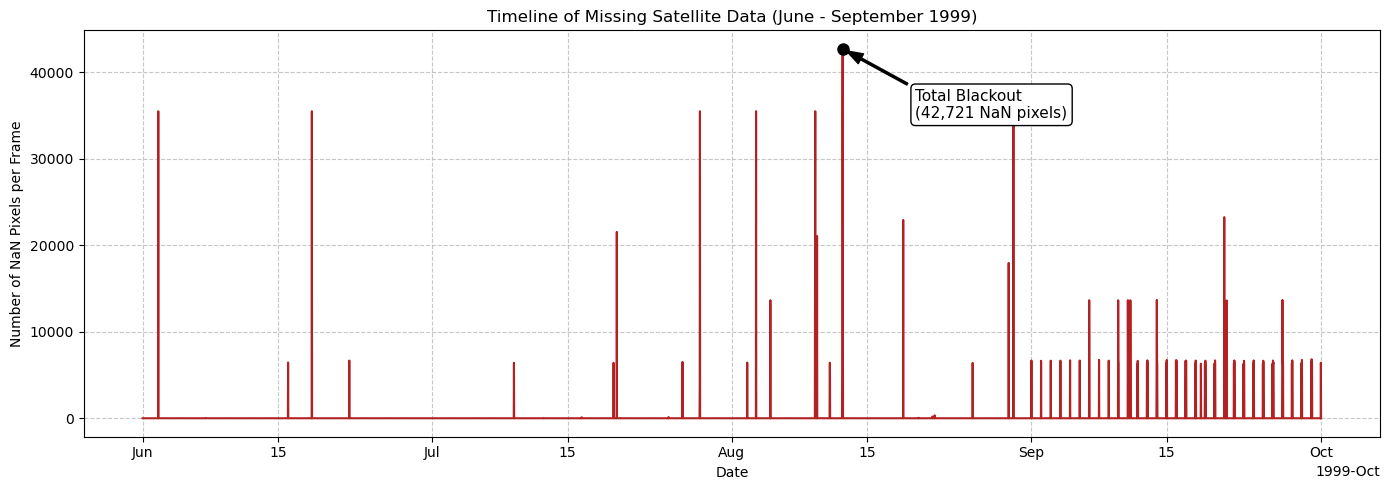

In [13]:
nans_over_time = ds_full.ctt.isnull().sum(dim=['lat', 'lon'])
blackout_time = '1999-08-12T11:00:00'
blackout_count = nans_over_time.sel(time=blackout_time).values


fig, ax = plt.subplots(figsize=(14, 5))
nans_over_time.plot(ax=ax, color='firebrick', linewidth=1.5)
ax.plot(pd.to_datetime(blackout_time), blackout_count, marker='o', color='black', markersize=8)
ax.annotate(
    f"Total Blackout\n({int(blackout_count):,} NaN pixels)", 
    xy=(pd.to_datetime(blackout_time), blackout_count),           # Where the arrow points
    xytext=(pd.to_datetime('1999-08-20'), blackout_count - 8000), # Where the text box lives
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black")
)

plt.title("Timeline of Missing Satellite Data (June - September 1999)")
plt.ylabel("Number of NaN Pixels per Frame")
plt.xlabel("Date")
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()